# GISC 4381/6321 — Lab 6: Point Pattern Analysis

This week's notebook covers the point pattern toolkit from lecture: visualizing point patterns,
centrography, spatial interpolation (IDW and kriging), and testing for clustering (quadrat
statistics, Ripley's G, and DBSCAN). We'll use **real, live crime incident data** from the City of
Chicago's open data portal.

Every distance-based method in this notebook (centrography, IDW, kriging, the quadrat test,
Ripley's G, DBSCAN) needs distances measured in real, consistent units. Latitude/longitude
degrees are **not** equidistant: a degree of longitude covers a different real distance depending
on latitude, and a degree of longitude is not the same real distance as a degree of latitude
anywhere except the equator. So right after loading the data, we'll reproject it into a **local
equidistant projection** built specifically for this study area, and do all of our analysis in
that projected coordinate system, in meters.

### Setup

If these aren't already installed in your environment:


In [ ]:
# !pip install geopandas pointpats scikit-learn pykrige matplotlib numpy scipy pandas pyproj


In [ ]:
# !pip install pointpats pykrige

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 6)


/tmp/ipykernel_515/1449544919.py:5: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


## 1. Getting Real Point Data

### Option A: Pull live data from the City of Chicago

Chicago's open data portal publishes reported crime incidents since 2001, updated daily, through a
public Socrata API. We'll grab the 2000 most recent real incidents.


In [2]:
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$limit=2000&$order=date%20DESC"
df = pd.read_json(url)

# A handful of records are missing coordinates (unable to be geocoded); drop those
df = df.dropna(subset=["latitude", "longitude"])

crimes = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",  # the API returns plain lat/lon (WGS84)
)

print(f"{len(crimes)} real crime incidents loaded")
crimes[["date", "primary_type", "description", "geometry"]].head()


1978 real crime incidents loaded


,date,primary_type,description,geometry
0,2026-09-16,BATTERY,DOMESTIC BATTERY SIMPLE,POINT (-87.71339 41.96917)
1,2026-09-16,THEFT,THEFT FROM MOTOR VEHICLE,POINT (-87.66976 41.80606)
2,2026-09-16,BURGLARY,BURGLARY FROM MOTOR VEHICLE,POINT (-87.76329 41.88325)
3,2026-09-16,ROBBERY,STRONG ARM - NO WEAPON,POINT (-87.65139 41.77965)
4,2026-09-16,ASSAULT,SIMPLE,POINT (-87.72873 41.88069)


> **Note:** this feed updates daily, so your sample (and every number downstream) will differ from
> lecture, from this notebook's cached-looking output, and from your classmates. That's expected,
> we're all working with whatever is real *right now*.

### Option B: PySAL's own example datasets

PySAL ships a library of classic, ready-to-use spatial datasets, several with point geometries.


In [3]:
import libpysal

# See everything that's available
libpysal.examples.available().head(15)


,Name,Description,Installed
0,10740,"Albuquerque, New Mexico, Census 2000 Tract Dat...",True
1,AirBnB,"Airbnb rentals, socioeconomics, and crime in C...",False
2,Atlanta,"Atlanta, GA region homicide counts and rates",False
3,Baltimore,Baltimore house sales prices and hedonics,False
4,Bostonhsg,Boston housing and neighborhood data,False
5,Buenosaires,Electoral Data for 1999 Argentinean Elections,False
6,Charleston1,"2000 Census Tract Data for Charleston, SC MSA...",False
7,Charleston2,1998 and 2001 Zip Code Business Patterns (Cen...,False
8,Chicago Health,Chicago Health + Socio-Economics,False
9,Chicago commpop,Chicago Community Area Population Percent Cha...,False


> **Try it:** browse the list above and pick one with point geometries. Load it with
> `libpysal.examples.load_example("NAME")` followed by
> `gpd.read_file(libpysal.examples.get_path("FILENAME.shp"))`, exactly like we did with Guerry a
> couple of weeks ago. Everything below works the same way regardless of which point dataset you
> feed it.

For the rest of this notebook we'll stick with the live Chicago crime data from Option A.


## 2. Projecting to a Local Equidistant CRS

Rather than picking an arbitrary standard projection, we'll build one **centered on this exact
dataset**: an azimuthal equidistant projection centered on the data's own centroid. This
guarantees that distances measured *from that center point outward* are true, real distances, in
meters, which is exactly what centrography and our clustering statistics need.


In [4]:
# For a set of points, the mean of x and mean of y *is* the geometric centroid
centroid_lon = crimes.geometry.x.mean()
centroid_lat = crimes.geometry.y.mean()
print("Centroid (lon, lat):", centroid_lon, centroid_lat)

local_aeqd = (
    f"+proj=aeqd +lat_0={centroid_lat} +lon_0={centroid_lon} "
    f"+datum=WGS84 +units=m +no_defs"
)

crimes_proj = crimes.to_crs(local_aeqd)
coords = np.column_stack([crimes_proj.geometry.x, crimes_proj.geometry.y])

print(coords[:3])  # now in meters from the centroid, not degrees


Centroid (lon, lat): -87.66810105645652 41.84217800966077
[[-3753.78175782 14106.3611524 ]
 [ -138.1017966  -4011.64383216]
 [-7900.94475756  4566.33160382]]


> **Think about it:** why center the projection on the data itself, rather than always using
> (say) the UTM zone for Chicago? What would go wrong if you analyzed a dataset from Puerto Rico
> using a projection built around Chicago's centroid?

## 3. Visualizing the Pattern


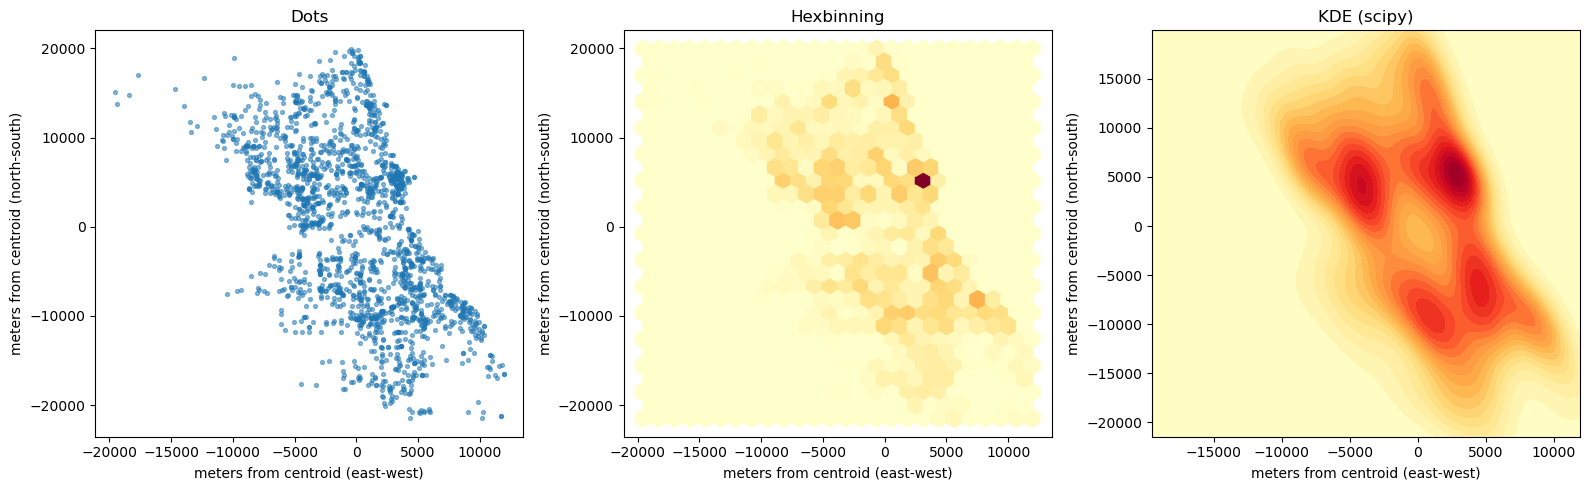

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.5)
axes[0].set_title("Dots")

axes[1].hexbin(coords[:, 0], coords[:, 1], gridsize=25, cmap="YlOrRd")
axes[1].set_title("Hexbinning")

kde = gaussian_kde(coords.T)
gx, gy = np.mgrid[coords[:,0].min():coords[:,0].max():150j,
                   coords[:,1].min():coords[:,1].max():150j]
density = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
axes[2].contourf(gx, gy, density, levels=20, cmap="YlOrRd")
axes[2].set_title("KDE (scipy)")

for ax in axes:
    ax.set_xlabel("meters from centroid (east-west)")
    ax.set_ylabel("meters from centroid (north-south)")
plt.tight_layout()
plt.show()


> **Try it yourself:** re-run the KDE cell with `gaussian_kde(coords.T, bw_method=0.1)` and then
> `bw_method=0.5`. Which one looks overfit? Which one looks underfit?


## 4. Centrography

PySAL's `pointpats` package implements the statistics from lecture directly: mean center, median
center, standard distance, and the standard deviational ellipse. Because `coords` is now in real
meters, `std_dist` below is a real, interpretable distance, not degrees.


In [6]:
from pointpats import centrography

mean_c = centrography.mean_center(coords)
med_c = centrography.euclidean_median(coords)
std_dist = centrography.std_distance(coords)

print("Mean center (m from centroid):  ", mean_c)
print("Median center (m from centroid):", med_c)
print(f"Standard distance: {std_dist:,.0f} meters")


Mean center (m from centroid):   [3.32894669 1.65452723]
Median center (m from centroid): [-143.81860659  686.68413768]
Standard distance: 10,654 meters


In [7]:
major, minor, rotation = centrography.ellipse(coords)
print(f"Semi-major: {major:,.0f} m, semi-minor: {minor:,.0f} m, rotation: {np.degrees(rotation):.1f} degrees")


Semi-major: 5,505 m, semi-minor: 11,942 m, rotation: -17.4 degrees


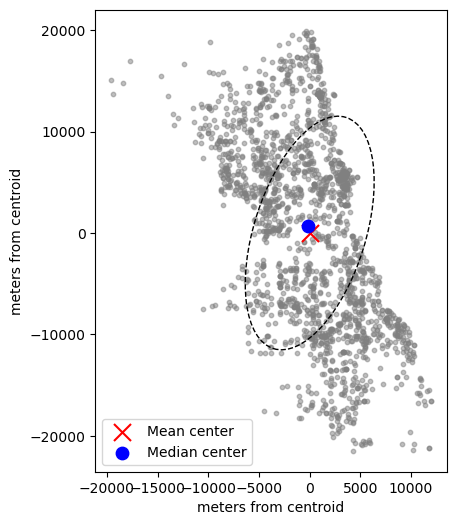

In [8]:
from matplotlib.patches import Ellipse as MplEllipse

fig, ax = plt.subplots()
ax.scatter(coords[:, 0], coords[:, 1], s=10, color="grey", alpha=0.5)
ax.scatter(*mean_c, color="red", marker="x", s=150, label="Mean center", zorder=5)
ax.scatter(*med_c, color="blue", marker="o", s=80, label="Median center", zorder=5)
ax.add_patch(MplEllipse(mean_c, 2 * major, 2 * minor, angle=np.degrees(rotation),
                          facecolor="none", edgecolor="black", linestyle="--"))
ax.legend()
ax.set_xlabel("meters from centroid"); ax.set_ylabel("meters from centroid")
ax.set_aspect("equal")
plt.show()


> **Note on package versions:** `pointpats`'s exact function names have shifted a little across
> releases (older versions used a `PointPattern` class wrapper). If a call above errors, run
> `import pointpats; help(pointpats.centrography)` to see what your installed version offers.

## 5. Extent: the Convex Hull

Now that we're in meters, the hull's area is a real, interpretable number (square meters), not
square degrees.


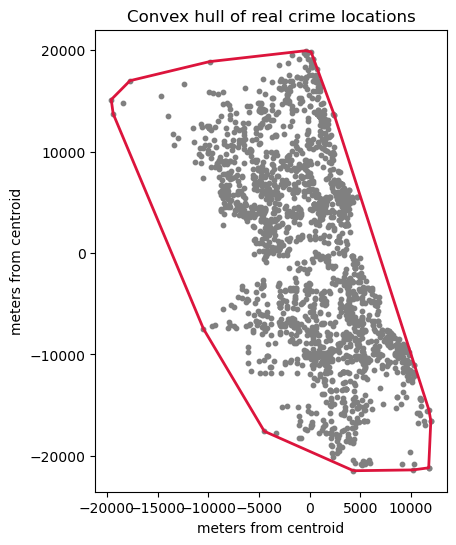

Hull area: 769,957,944 square meters (770.0 square km)


In [9]:
from shapely.geometry import MultiPoint

hull = MultiPoint(coords.tolist()).convex_hull

fig, ax = plt.subplots()
ax.scatter(coords[:, 0], coords[:, 1], s=10, color="grey")
gpd.GeoSeries([hull]).boundary.plot(ax=ax, color="crimson", linewidth=2)
ax.set_xlabel("meters from centroid"); ax.set_ylabel("meters from centroid")
ax.set_aspect("equal")
ax.set_title("Convex hull of real crime locations")
plt.show()

print(f"Hull area: {hull.area:,.0f} square meters ({hull.area / 1e6:,.1f} square km)")


## 6. Spatial Interpolation

We don't have a magnitude-like measurement for crimes, so let's interpolate something we do have:
**time of day**. Convert `date` to hour-of-day (0-23) and interpolate that.

### IDW, by hand


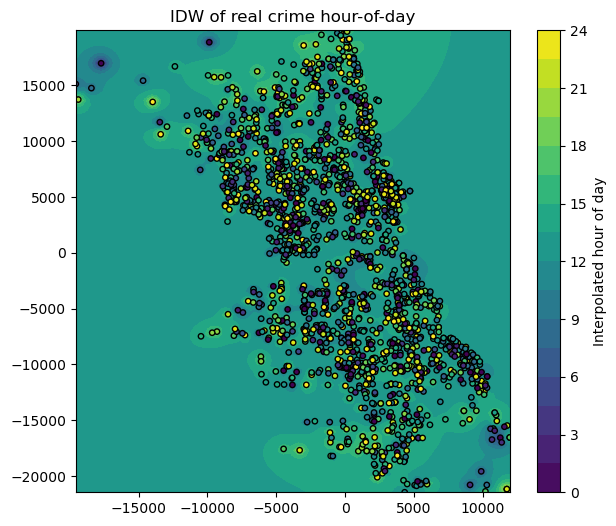

In [10]:
crimes_proj["hour"] = pd.to_datetime(crimes_proj["date"]).dt.hour
z = crimes_proj["hour"].values

def idw(grid_pts, sample_pts, sample_z, power=2):
    d = np.sqrt(((grid_pts[:, None, :] - sample_pts[None, :, :]) ** 2).sum(axis=2))
    d = np.where(d == 0, 1e-12, d)
    w = 1.0 / (d ** power)
    return (w * sample_z[None, :]).sum(axis=1) / w.sum(axis=1)

gx2, gy2 = np.mgrid[coords[:,0].min():coords[:,0].max():120j,
                     coords[:,1].min():coords[:,1].max():100j]
grid_pts = np.column_stack([gx2.ravel(), gy2.ravel()])

idw_z = idw(grid_pts, coords, z, power=2).reshape(gx2.shape)

fig, ax = plt.subplots()
cf = ax.contourf(gx2, gy2, idw_z, levels=20, cmap="viridis")
plt.colorbar(cf, ax=ax, label="Interpolated hour of day")
ax.scatter(coords[:, 0], coords[:, 1], c=z, cmap="viridis", edgecolor="black", s=15)
ax.set_title("IDW of real crime hour-of-day")
plt.show()


### Kriging, with a real package


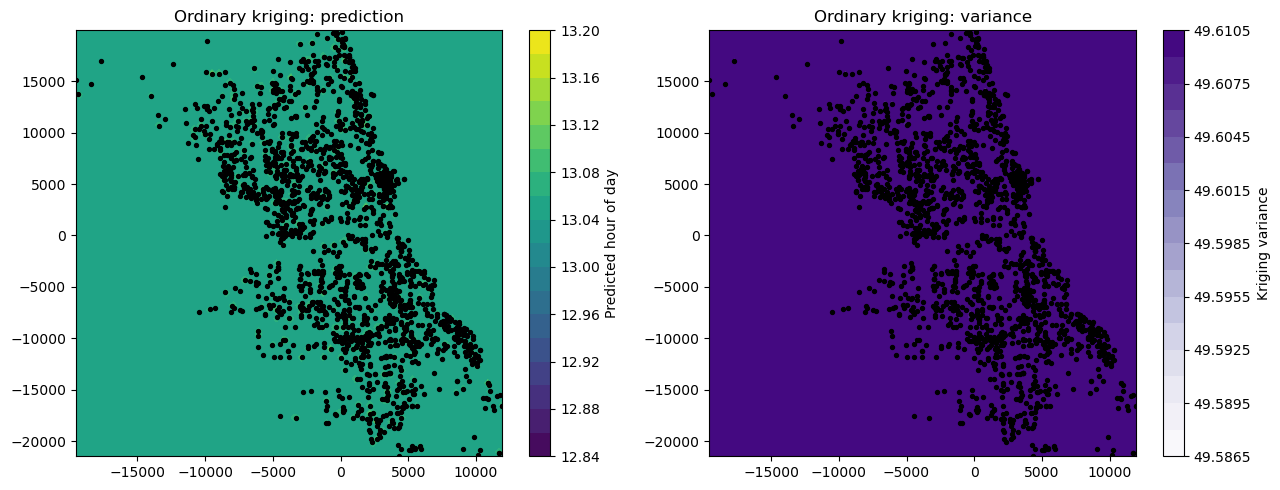

[  0.82119508 162.17118725  48.76339544]


In [11]:
from pykrige.ok import OrdinaryKriging

ok = OrdinaryKriging(
    coords[:, 0], coords[:, 1], z,
    variogram_model="exponential",
    verbose=False, enable_plotting=False,
)

grid_x = np.linspace(coords[:,0].min(), coords[:,0].max(), 120)
grid_y = np.linspace(coords[:,1].min(), coords[:,1].max(), 100)
krige_z, krige_var = ok.execute("grid", grid_x, grid_y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cf1 = axes[0].contourf(grid_x, grid_y, krige_z, levels=20, cmap="viridis")
plt.colorbar(cf1, ax=axes[0], label="Predicted hour of day")
axes[0].set_title("Ordinary kriging: prediction")
cf2 = axes[1].contourf(grid_x, grid_y, krige_var, levels=20, cmap="Purples")
plt.colorbar(cf2, ax=axes[1], label="Kriging variance")
axes[1].set_title("Ordinary kriging: variance")
for ax in axes:
    ax.scatter(coords[:, 0], coords[:, 1], color="black", s=8)
plt.tight_layout()
plt.show()

print(ok.variogram_model_parameters)


> **Discuss:** would you actually expect crime *time of day* to have strong spatial structure
> (nearby places sharing similar typical hours), or is this more like the earthquake magnitude
> example from lecture, mostly noise? What does the fitted variogram tell you?

## 7. Randomness and Clustering

Now that `coords` is in real meters, `support` values below are real distances, not degrees, so
they're directly interpretable (e.g., "500 meters"), and comparable across different datasets.

### Quadrat test


In [12]:
from pointpats import QStatistic

qstat = QStatistic(coords)
print("Chi-square statistic:", qstat.chi2)
print("p-value:", qstat.chi2_pvalue)


Chi-square statistic: 1632.6926188068758
p-value: 0.0


> **Note on versions:** if `QStatistic` isn't found, check `import pointpats; dir(pointpats)` for
> the equivalent in your installed version.

### Ripley's G function, with a simulation envelope

*This one takes a while to run*

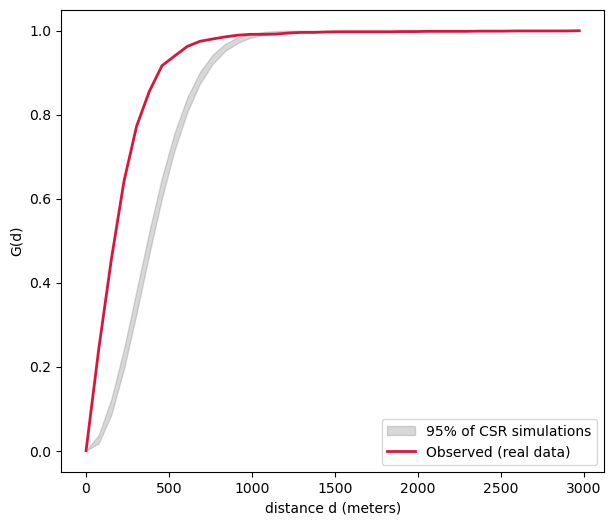

In [13]:
from pointpats.distance_statistics import g_test

g_result = g_test(coords, support=40, keep_simulations=True)

fig, ax = plt.subplots()
sims = g_result.simulations
ax.fill_between(g_result.support, np.percentile(sims, 2.5, axis=0), np.percentile(sims, 97.5, axis=0),
                 color="grey", alpha=0.3, label="95% of CSR simulations")
ax.plot(g_result.support, g_result.statistic, color="crimson", linewidth=2, label="Observed (real data)")
ax.set_xlabel("distance d (meters)")
ax.set_ylabel("G(d)")
ax.legend()
plt.show()


> **Note on versions:** older `pointpats` releases used a `Genv` class built from a `PointPattern`
> object instead of this functional API. The underlying math is identical either way.

## 8. Identifying Clusters: DBSCAN

`eps` is now a real distance in meters, e.g. `eps=200` means "200 meters," not an arbitrary
number of degrees.


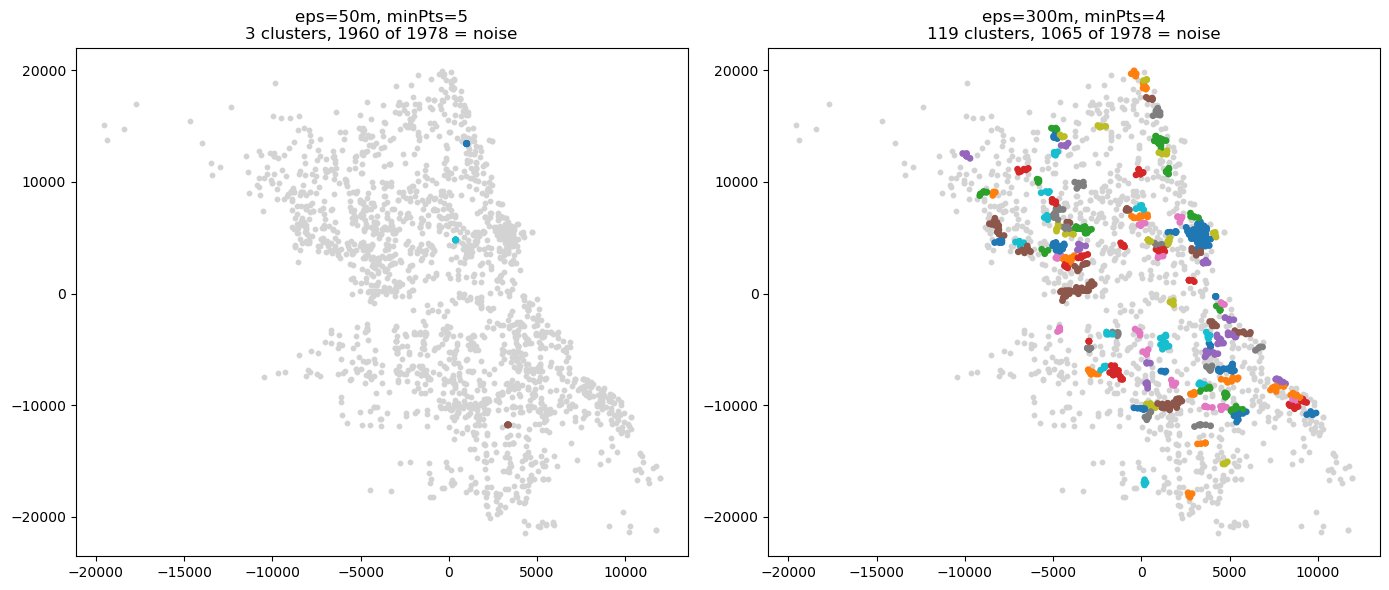

In [14]:
db_tight = DBSCAN(eps=50, min_samples=5).fit(coords)
db_loose = DBSCAN(eps=300, min_samples=4).fit(coords)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, title in zip(axes, [db_tight.labels_, db_loose.labels_],
                               ["eps=50m, minPts=5", "eps=300m, minPts=4"]):
    noise = labels == -1
    ax.scatter(coords[noise, 0], coords[noise, 1], s=10, color="lightgrey")
    ax.scatter(coords[~noise, 0], coords[~noise, 1], s=15, c=labels[~noise], cmap="tab10")
    n_clusters = len(set(labels[~noise]))
    ax.set_title(f"{title}\n{n_clusters} clusters, {noise.sum()} of {len(coords)} = noise")
plt.tight_layout()
plt.show()


## Learn More / Going Further

- Try the whole notebook on a different real dataset: pick anything from
  `libpysal.examples.available()` with point geometries, or filter the Chicago API to a single
  `primary_type` (e.g. `$where=primary_type='THEFT'`) to study one crime category at a time.
- `pointpats` also has an `f_test` (the complementary "empty space" function from lecture) and a
  `k_test`/`l_test` pair for Ripley's K and L. Try one, in the same projected meters.
- `pykrige` supports several variogram models beyond `"exponential"` (`"gaussian"`,
  `"spherical"`, `"linear"`). Try refitting and compare the parameters.
- For a real challenge: reproject the same data to plain UTM (e.g. `EPSG:32616` for Chicago) and
  re-run the quadrat test and Ripley's G. Do your conclusions change compared to the local
  azimuthal equidistant projection we used here? For a dataset this size and this local in extent,
  you likely won't see a big difference, but for a larger study area the choice can matter a lot.
